## Risk & Return Analysis of Indian IT Stocks
### Time Period: FY 2018 - 2026 

### OBJECTIVE
This report analyzes **Monthly Closing Prices** of selected Indian Information Technology (IT) equities from Financial Year 2018- 2026 to study return behaviour, Volatility and inter-stock relationship within the sector and propose a simple risk-based Investment Idea

In [1]:
# Install necessary libraries
%pip install yfinance pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\NIMISH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
%pip show yfinance

Name: yfinance
Version: 1.3.0
Summary: Download market data from Yahoo! Finance API
Home-page: https://github.com/ranaroussi/yfinance
Author: Ran Aroussi
Author-email: ran@aroussi.com
License: Apache
Location: C:\Users\NIMISH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages
Requires: beautifulsoup4, curl_cffi, frozendict, multitasking, numpy, pandas, peewee, platformdirs, protobuf, pytz, requests, websockets
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf # checking if library is successfully installed
print(yf.__version__) 

1.3.0


In [4]:
#-----------------
# IMPORT LIBRARIES
#-----------------
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [5]:
#-----------------
# LIST OF IT STOCKS
#-----------------
stocks = {
    "Infosys": "INFY.NS",
    "HCLTech": "HCLTECH.NS",
    "TechM": "TECHM.NS",
    "OFSS": "OFSS.NS",
}

#### DOWNLOAD   MONTHLY DATA 
Source = Yahoo Finance (yfinance)
Monthly data was selected instead of weekly data to reduce short-term market noise and better capture trend behavior in IT equities.
This also improved interpretations of the visuals and reduced overtrading.

In [6]:

data = yf.download(
    list(stocks.values()),
    start= "2018-04-01",
    end= "2026-03-31",
    interval="1mo",
    auto_adjust=True,
    threads = False,
    progress = False
)
data = data["Close"]


# Rename columns for readability
data.columns = stocks.keys()
print("\nMonthly Closing Prices")


print(data.head(20))



Monthly Closing Prices
               Infosys     HCLTech        TechM        OFSS
Date                                                       
2018-04-01  409.155365  481.917206  2930.681396  507.515717
2018-05-01  353.811066  494.894135  2681.001465  539.112549
2018-06-01  360.774750  525.187195  2770.619873  496.050262
2018-07-01  375.906891  561.892883  2637.076172  515.197388
2018-08-01  407.592834  593.175537  2828.756348  592.707031
2018-09-01  424.566376  600.996094  2753.142334  576.995483
2018-10-01  411.998688  565.062256  2547.383545  575.757263
2018-11-01  396.958069  555.445679  2417.369629  546.385010
2018-12-01  377.149261  548.372192  2606.433105  559.697327
2019-01-01  393.125336  623.768494  2672.020020  566.469360
2019-02-01  412.171509  614.436890  2461.691895  642.512146
2019-03-01  426.108398  622.428040  2381.518066  600.524231
2019-04-01  463.685913  628.703613  2474.309814  647.117310
2019-05-01  428.106750  617.323730  2402.923096  588.488892
2019-06-01  417.

In [7]:
#------------------------
# HANDLING MISSING VALUES
#------------------------

# Drop columns with too many missing values 
data = data.dropna(axis=1, thresh =len(data)*0.8)
print(data.columns)

Index(['Infosys', 'HCLTech', 'TechM', 'OFSS'], dtype='str')


In [8]:
#------------------------
# CALCULATE MONTHLY RETURN
# Measures month-to-month percentage change in stock prices

monthly_returns = data.pct_change().dropna()  # dropna removes first NaN value from calculation

# Display as percentage
monthly_returns_pct = (monthly_returns * 100).round(2)

print(monthly_returns_pct.head())

            Infosys  HCLTech  TechM   OFSS
Date                                      
2018-05-01   -13.53     2.69  -8.52   6.23
2018-06-01     1.97     6.12   3.34  -7.99
2018-07-01     4.19     6.99  -4.82   3.86
2018-08-01     8.43     5.57   7.27  15.04
2018-09-01     4.16     1.32  -2.67  -2.65


## VISUAL 1 : NORMALIZED PRICE PERFORMANCE

Prices were normalized to a base value of 100 to enable relative performance comparison across stocks with different absolute price levels.

Example:
 - Infosys Trading price 1000
 - OFSS Trading price 8000
        
         Raw prices OFSS will always dominate the chart, comparison becomes misleading

A logarithmic scale was used to better visualize compounded percentage returns over time and improve comparability across equities

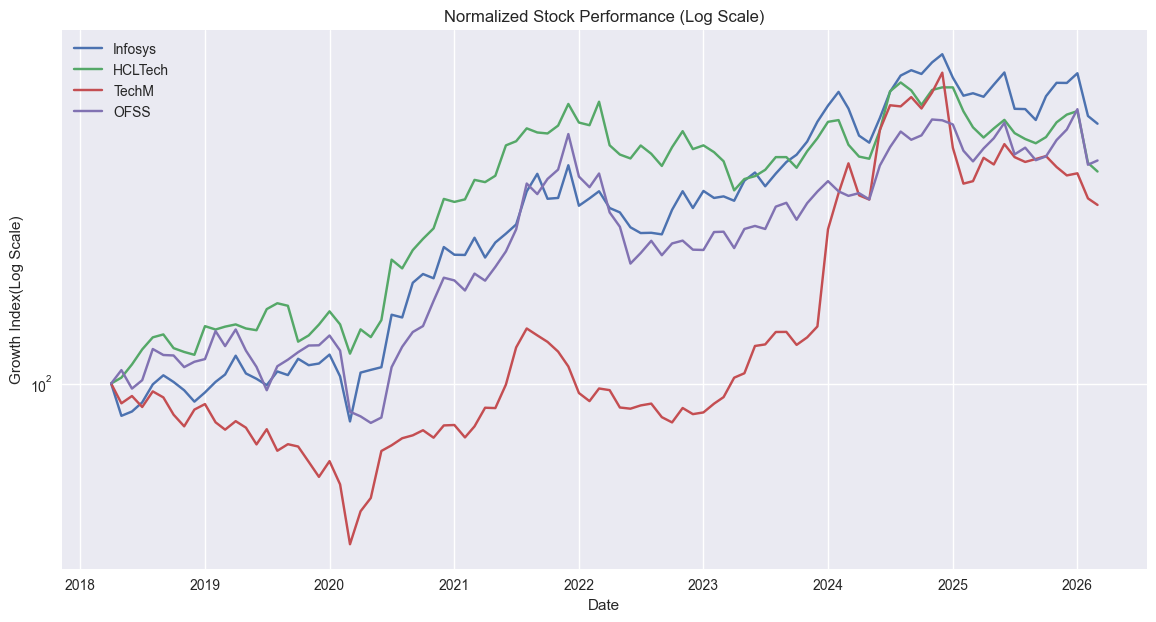

In [9]:

normalized = data / data.iloc[0] * 100

plt.figure(figsize=(14,7))

for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.yscale("log")
plt.title("Normalized Stock Performance (Log Scale)") # Title of the graph plot
plt.xlabel("Date") # x axis
plt.ylabel("Growth Index(Log Scale)") # y axis
plt.legend()
plt.grid(True)
plt.show()

#### COMPOUND ANNUAL GROWTH RATE

In [10]:
start_price = data.iloc[0]
end_price = data.iloc[-1]

years = len(data)/12

cagr_alt = (end_price/start_price) ** (1 / years) -1

print("CAGR (%):")
print((cagr_alt * 100).round(2).sort_values(ascending= False))


CAGR (%):
Infosys    15.73
OFSS       13.36
HCLTech    12.66
TechM      10.56
dtype: float64


#### ANNUALIZED VOLATILITY ANALYSIS
Measures price fluctuations (Risk)
Higher Volatility = Higher Uncertainty/risk

In [11]:

annualized_volatility = monthly_returns.std() * np.sqrt(12)

print("Annualized_Volatility:")
print(annualized_volatility.sort_values(ascending=False))

print("""
       Tech Mahindra is highly volatile stock among 4 stocks""")

Annualized_Volatility:
TechM      0.365220
OFSS       0.297995
Infosys    0.285591
HCLTech    0.267043
dtype: float64

       Tech Mahindra is highly volatile stock among 4 stocks



## VISUAL 2 : ROLLING VOLATILITY PLOT

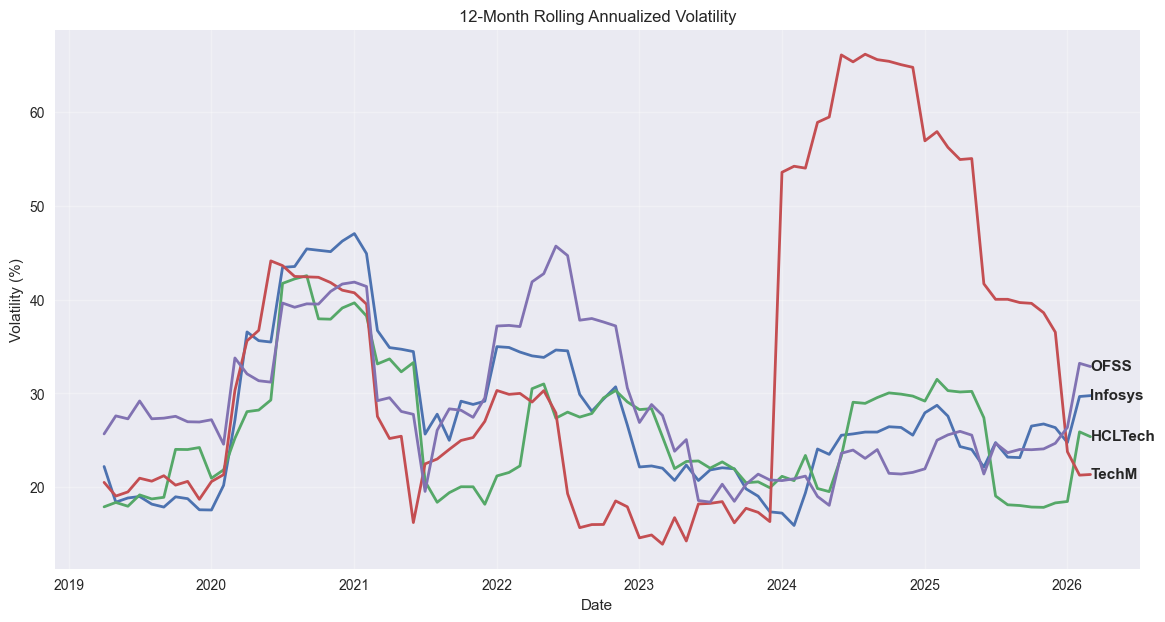

In [26]:
rolling_volatility = monthly_returns.rolling(window=12).std() * np.sqrt(12) * 100

plt.figure(figsize=(14,7))

for col in rolling_volatility.columns:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[col],
        label=col,
        linewidth=2
    )
 # Add label at the end of each line
    plt.text(
        rolling_volatility.index[-1],                 # last x point
        rolling_volatility[col].dropna().iloc[-1],   # last y point
        col,
        fontsize=11,
        fontweight='bold',
        va='center'
    )
plt.title("12-Month Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")


plt.grid(alpha=0.3)


plt.show()

#### CORRELATION MATRIX

In [13]:

corr_matrix = monthly_returns.corr()

print("\nCorrelation Matrix")
print(corr_matrix)


Correlation Matrix
          Infosys   HCLTech     TechM      OFSS
Infosys  1.000000  0.695410  0.433623  0.660984
HCLTech  0.695410  1.000000  0.373596  0.650872
TechM    0.433623  0.373596  1.000000  0.338074
OFSS     0.660984  0.650872  0.338074  1.000000


## VISUAL 3: CORRELATION HEATMAP
Correlation between monthly returns was analyzed to assess diversification benefits within the IT sector

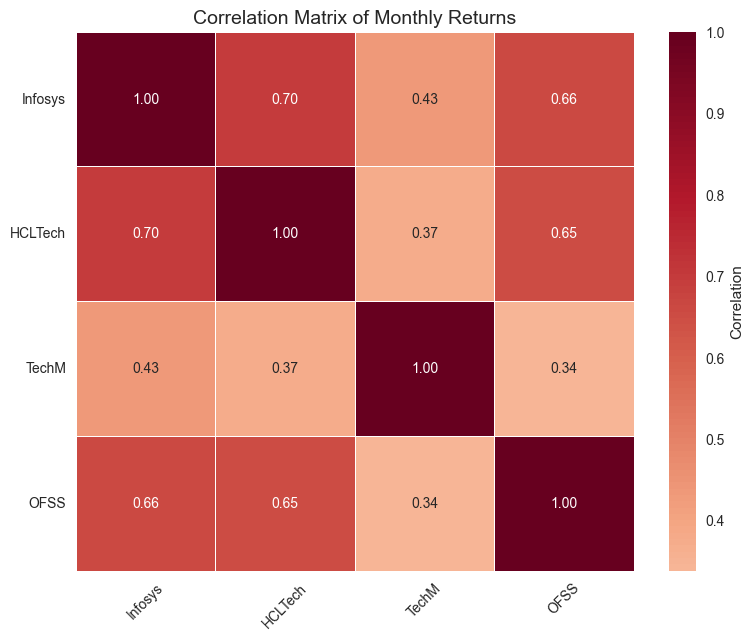

In [14]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt= ".2f",
    cmap="RdBu_r",
    center= 0,
    linewidths=0.5,
    cbar_kws= {"label" : "Correlation"}
)

plt.title("Correlation Matrix of Monthly Returns" , fontsize = 14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

#### DRAWDOWN ANALYSIS

In [15]:

cumulative_returns = (1 + monthly_returns).cumprod()

rolling_max = cumulative_returns.cummax()

drawdown = (cumulative_returns - rolling_max) / rolling_max


# VISUAL 4 :  DRAWDOWNS

The line chart is smoothed for better readability 

Price at new high --> drawdown = 0

Price falls --> drawdown = negative

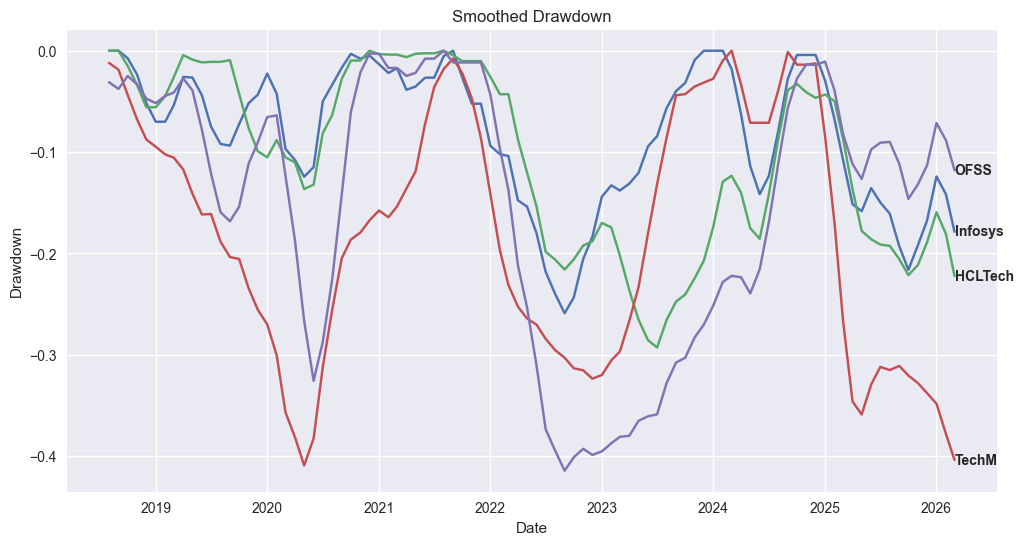

In [28]:
smoothed_dd = drawdown.rolling(4).mean()
plt.figure(figsize=(12,6))
for col in smoothed_dd.columns[:4]:  
    plt.plot(smoothed_dd.index, smoothed_dd[col], label=col)

# Label at the end of each line
    plt.text(
        smoothed_dd.index[-1],                 # last date
        smoothed_dd[col].dropna().iloc[-1],   # last drawdown value
        col,
        fontsize=10,
        fontweight='bold',
        va='center'
    )


plt.title("Smoothed Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

## TRADING/RISK IDEA for Tech Mahindra stock due to high volatility
Closing Price > EMA(10) => BUY or Stay Invested

Closing Price < EMA(10) => SELL   Reduce 50% allocation and later buy when closing price is above EMA (10) 

WEAKNESS

- Overfitting: strategy worked historically may fail future regimes
- Limited macro context : Analysis Ignores - interest rates, USD/INR effects, Global tech sentiment
- Transaction cost: frequently rebalancing may reduce profitability

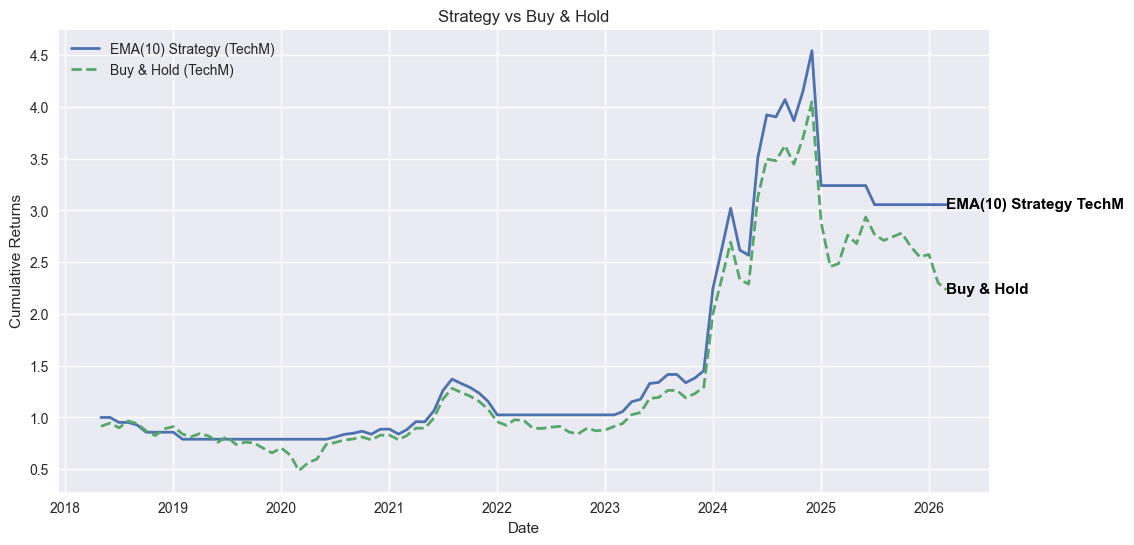

In [ ]:

monthly_returns.columns

stocks = ["TechM"]  # replace with real names
data = monthly_returns[stocks]

price = (1 + data).cumprod()

# 10 - month EMA
ema = price.ewm(span=10, adjust=False).mean()

# Trading Signal
signal = (price > ema).astype(int).shift(1)

# Strategy Return
strategy_returns = data * signal

# porfolio strategy
portfolio_strategy = strategy_returns.mean(axis=1)
portfolio_market = data.mean(axis=1)

#Cumulative returns
strategy_cum = (1 + portfolio_strategy.fillna(0)).cumprod()
market_cum = (1 + portfolio_market.fillna(0)).cumprod()

plt.figure(figsize=(12,6))

plt.plot(strategy_cum, label="EMA(10) Strategy (TechM)", linewidth=2)
plt.plot(market_cum, label="Buy & Hold (TechM)", linewidth=2, linestyle="--")

plt.text(
    market_cum.index[-1],
    market_cum.iloc[-1],
    "Buy & Hold",
    fontsize=11,
    fontweight='bold',
    va='center',
    color='black'
)

plt.text(
    strategy_cum.index[-1],
    strategy_cum.iloc[-1],
    "EMA(10) Strategy TechM",
    fontsize=11,
    fontweight='bold',
    va='center',
    color='black'
)

plt.title("Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")

plt.grid(True)
plt.show()

In [18]:
#CLEAN RETURNS
strategy_returns = portfolio_strategy.dropna()
market_returns = portfolio_market.dropna()

In [43]:
#ANNUALIZATION SETUP
periods = 12

In [44]:
#RETURNS
strategy_ann_return = strategy_returns.mean() * periods
market_ann_return = market_returns.mean() * periods

In [45]:
# Function to calculate CAGR
def calculate_cagr(cum_series, periods_per_year):
    total_years = len(cum_series) / periods_per_year
    return (cum_series.iloc[-1] ** (1 / total_years)) - 1

# CAGR
strategy_cagr = calculate_cagr(strategy_cum, periods)
market_cagr = calculate_cagr(market_cum, periods)

In [49]:
strategy_vol = strategy_returns.std() * np.sqrt(12)
market_vol = market_returns.std()*np.sqrt(12)

# Sharpe Ratio (assuming risk-free rate = 0)
strategy_sharpe = strategy_cagr / strategy_vol
market_sharpe = market_cagr / market_vol

In [50]:
#MAX DRAWDOWN

# Max Drawdown
def max_drawdown(cum_series):
    rolling_max = cum_series.cummax()
    drawdown = cum_series / rolling_max - 1
    return drawdown.min()

strategy_mdd = max_drawdown(strategy_cum)
market_mdd = max_drawdown(market_cum)


In [51]:

# Performance Table
performance_matrix = pd.DataFrame({
    "EMA10 Strategy": [
        strategy_cagr,
        strategy_vol,
        strategy_sharpe,
        strategy_mdd
    ],
    "Buy & Hold": [
        market_cagr,
        market_vol,
        market_sharpe,
        market_mdd
    ]
}, index=[
    "CAGR",
    "Annual Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
])

print("\n================ PERFORMANCE MATRIX ================\n")
print(performance_matrix)


================ PERFORMANCE MATRIX ================

                                     EMA10 Strategy  Buy & Hold
CAGR                                       0.151504    0.106788
Annual Volatility  TechM    0.310312
dtype: float64    0.365220
Sharpe Ratio        TechM    0.48823
dtype: float64    0.292394
Max Drawdown                              -0.327312   -0.497107
